# Misure ripetute e inferenza bayesiana

In generale, vedremo che la presenza di più misure ripetute ha l'effetto di ridurre l'intevello di incertezza rispetto al caso con un numero di misure più piccolo.

Partiamo sempre da una distribuzione gaussiana per una variabile $x$ con valor medio $\mu$ e deviazione standard $\sigma$.

Ma questa volta consideriamo $n$ osservazioni, o misure, $x_1, \cdots, x_n$.

La distribuzione di probabilità congiunta è:

$\displaystyle f(x_1, \cdots, x_n;\theta) = \prod_{i=1}^n f(x_i;\theta)$

Nel caso gaussiano:

$\displaystyle f(x_1, \cdots, x_n;\mu,\sigma) = \prod_{i=1}^n g(x_i; \mu, \sigma)=\frac{1}{(2\pi\sigma^2)^{n/2}} \exp\left[{-\sum_{i=1}^n\frac{(x_i-\mu)^2}{2\sigma^2}}\right]$

La distribuzione a posteriori per $\mu$ si può scrivere, se $\sigma$ è noto, come:

$\displaystyle f(\mu;x_1,\cdots,x_n) = \frac{f(x_1, \cdots, x_n;\mu,\sigma)\,\pi(\mu)}{\int f(x_1, \cdots, x_n;\mu^\prime,\sigma)\,\pi(\mu^\prime)\,\mathrm{d}\mu^\prime}$

Se assumiamo una probabilità a priori uniforme per $\mu$, ossia $\pi(\mu)=\mathrm{cost.}$, diventa:

$\displaystyle f(\mu;x_1, \cdots, x_n) = 
\frac{1}{(2\pi\sigma^2)^{n/2}} \exp\left[{-\sum_{i=1}^n\frac{(x_i-\mu)^2}{2\sigma^2}}\right] \Biggm/ \int_{-\infty}^{+\infty} \frac{1}{(2\pi\sigma^2)^{n/2}} \exp\left[{-\sum_{i=1}^n\frac{(x_i-\mu^\prime)^2}{2\sigma^2}}\right]\,\mathrm{d}\mu^\prime$

$\displaystyle = C \exp\left[{-\sum_{i=1}^n\frac{(x_i-\mu)^2}{2\sigma^2}}\right]$

Dove $C$ è una costante di normalizzazione definita come:

$\displaystyle  \frac{1}{C} = \int_{-\infty}^{+\infty}\!\!\!\!\!  \exp\left[{-\sum_{i=1}^n\frac{(x_i-\mu^\prime)^2}{2\sigma^2}}\right]\,\mathrm{d}\mu^\prime$

Va notato che la forma:

$\displaystyle\Sigma=\sum_{i=1}^n(x_i-\mu)^2$

È un polinomio di secondo grado in $\mu$:

$\displaystyle\Sigma=\sum_{i=1}^n(\mu^{2} - 2x_i\mu+ x_i^2) = 
n \mu^{2} - 2\mu \sum_{i=1}^n x_i + \sum_{i=1}^n x_i^2 =
n\left(\mu^{2}  - 2\mu \frac{1}{n}\sum_{i=1}^n x_i + \frac{1}{n}\sum_{i=1}^n x_i^2
\right)
$

Se definiamo, come al solito:

$\displaystyle \bar{x} = \frac{1}{n}\sum_{i=1}^n x_i$

$\displaystyle \overline{x^2} = \frac{1}{n}\sum_{i=1}^n x_i^2$

e avendo definito: 

$\displaystyle\sigma_{\bar{x}}^2 = \frac{1}{n}(\overline{x^2} - \bar{x}^2)=\frac{\sigma^2}{n}$

In sostanza, la PDF a posteriori è ancora una gaussiana:

$\displaystyle\Sigma=n\left(
\mu^2 - 2\mu\bar{x} + \overline{x^2}
\right)
=  n\left(
\mu^2 - 2\mu\bar{x} + \overline{x}^2 - \overline{x}^2 + \overline{x^2}
\right)
=  n\left(
(\mu - \bar{x})^2 + (\overline{x^2} -\bar{x}^2)
\right)
=  n\left(
(\mu - \bar{x})^2 + \sigma_{\bar{x}}^2\right)$


Tornando alla nostra PDF:

$\displaystyle f(\mu | x_1, \cdots, x_n) = C \exp\left[{-\frac{\Sigma}{2\sigma^2}}\right] =
C \exp\left[{-\frac{n\left(
(\mu - \bar{x})^2 + \sigma_{\bar{x}}^2\right)}{2\sigma^2}}\right]=
C \exp\left[{-\frac{n\left(
\mu - \bar{x}\right)^2}{2\sigma^2}}\right]\exp\left(-\frac{n\sigma_{\bar{x}}^2}{2\sigma^2}\right)$

La possiamo anche scrivere come:

$\displaystyle f(\mu | x_1, \cdots, x_n) = C^\prime \exp\left[{-\frac{(\mu - \bar{x})^2}{2\sigma^2_{\overline{x}}}}\right]$


Siccome la distribuzione è gaussiana, la costante di normalizzazione la conosciamo:

$\displaystyle f(\mu | x_1, \cdots, x_n) = \frac{1}{\sqrt{2\pi\sigma^2_{\overline{x}}}} \exp\left[{-\frac{(\mu - \bar{x})^2}{2\sigma^2_{\overline{x}}}}\right]$

<span style="color: blue;">L'effetto netto di avere $n$ misure, quindi, è di ridurre la deviazione standard della PDF di un fattore $\sqrt{n}$ rispetto alla singola misura.</span>

Il valore più probabile di $\mu$ è $\mu=\hat{\mu} = \bar{x}$, e la deviazione standard della PDF a posteriori è $\sigma/\sqrt{n}$.

In [1]:
from scipy.stats import norm
from scipy import integrate
import matplotlib.pyplot as plt
import numpy as np
import math

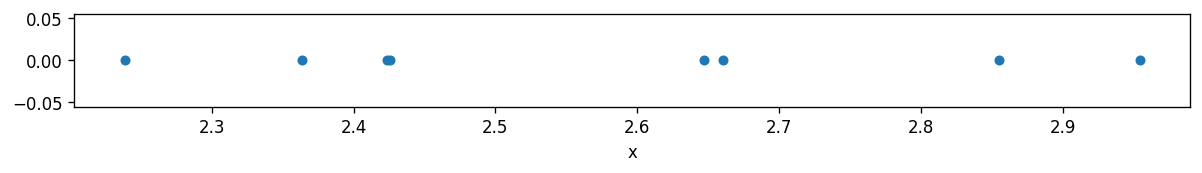

In [2]:
sigma = 0.4
mu = 2.5
x_obs = norm.rvs(loc=mu, scale=sigma, size=8)
plt.figure(figsize=(12,1), dpi=120)
plt.plot(x_obs, np.zeros(len(x_obs)), '.', markersize=10)
plt.xlabel('x')
plt.show()

Grafichiamo la funzione di verosimiglianza, che è anche uguale alla posterior se la prior $\pi(\mu)$ è assunta essere una costante:

In [3]:
def likelihood(mu):
    return norm.pdf(x_obs.mean(), loc=mu, scale=sigma/math.sqrt(len(x_obs)))

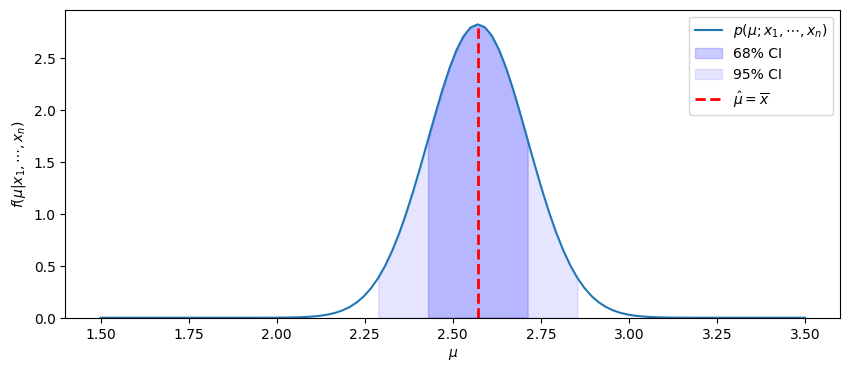

In [4]:
mu0 = x_obs.mean()
s0 = sigma/math.sqrt(len(x_obs))

mu_range=np.linspace(1.5, 3.5, 100)

x_1s = np.linspace(mu0-s0, mu0+s0, 100)
y_1s = likelihood(x_1s)

x_2s = np.linspace(mu0-2*s0, mu0+2*s0, 100)
y_2s = likelihood(x_2s)

plt.figure(figsize=(10, 4))
plt.plot(mu_range, likelihood(mu_range), label=r'$p(\mu;x_1,\cdots,x_n)$')
plt.fill_between(x_1s, y_1s, alpha=0.2, color='blue', label='68% CI')
plt.fill_between(x_2s, y_2s, alpha=0.1, color='blue', label='95% CI')
plt.plot([mu0, mu0], [0, likelihood(mu0)], color='red', linewidth=2, linestyle='--', label=r'$\hat{\mu}=\overline{x}$')
plt.ylim(bottom=0)
plt.xlabel(r'$\mu$')
plt.ylabel(r'$f(\mu|x_1,\cdots,x_n)$')
plt.legend()
plt.show()

## Distribuzione esponenziale

La distribuzione di probabilità congiunta, nel caso esponenziale, è:

$\displaystyle f(x_1, \cdots, x_n;\lambda) = \prod_{i=1}^n \lambda\exp\left(-\lambda x_i
\right) =
\lambda^n \exp\left(-\lambda\sum_{i=1}^n x_i
\right) =
\lambda^n \exp(-n\lambda\bar{x})
$

Un caso simile lo abbiamo già visto in precedenza.

<span style="color:red">**Nota**: se avessi definito la PDF come:</span>
    
<span style="color:red">$\displaystyle f(x;\tau) = \frac{1}{\tau} \exp(-x/\tau)$</span>
    
<span style="color:red">La PDF a posteriori per $\tau$ avrebbe avuto una forma diversa. **Assumere $\pi(\lambda)$ uniforme non equivale ad assumere $\pi(\tau)$ uniforme!**
</span>

La PDF aposteriori, se $\pi(\lambda)$ è una costante, si può scrivere come $p(x_1, \cdots, x_n;\lambda)$ moltiplicato un fattore di normalizzazione rispetto a $\lambda$.

$\displaystyle f(\lambda; x_1, \cdots, x_n;) = C\,f(x_1, \cdots, x_n;\lambda)
= C\,\lambda^n \exp(-n\lambda\bar{x})$

$C$ si può calcolare analiticamente in questo caso, oppure, in generale, numericamente.

Questa funzione è una distribuzione *gamma*:

$\displaystyle \gamma(x; \kappa, \theta) = \frac{x^{\kappa-1}e^{-x/\theta}}{\theta^\kappa\Gamma(\kappa)}$

Nel nostro caso: $\kappa = n+1$ e $\theta = 1/n\bar{x}$ e $\Gamma(\kappa)=n!$:

$\displaystyle f(\lambda; x_1, \cdots, x_n;)
= (n\bar{x})^{n+1}\lambda^n \exp(-n\lambda\bar{x})/n!$

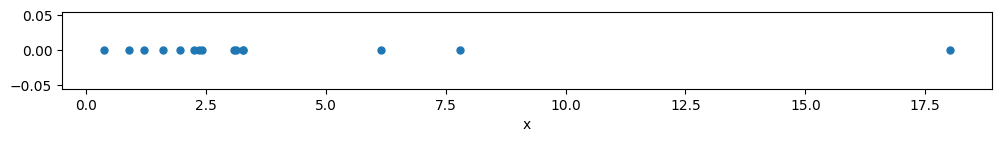

In [6]:
from scipy.stats import expon
lam = 0.4
x_obs = expon.rvs(scale=1/lam, size=15)
plt.figure(figsize=(12, 1))
plt.plot(x_obs, np.zeros(len(x_obs)), '.', markersize=10)
plt.xlabel('x')
plt.show()

Gli argomenti della funzione di verosimiglianza sono definiti di seguito. Potremmo usare la distribuzione gamma direttamente dalla librera, in questo esempio, invece, esplicitiamo il calcolo:

In [7]:
x_sum=x_obs.sum()
x_size = len(x_obs)
print("sum: ", x_sum)
print("size: ", x_size)

sum:  57.78613989336459
size:  15


Si può dimostrare facilmente per via analitica che il valore massimo della PDF a posteriori è pari a:

$\hat{\lambda} = 1/\bar{x}$

Il calcolo analitico del fattore di normalizzazione $C$ richiede l'uso delle [funzioni $\Gamma$](https://mathworld.wolfram.com/GammaFunction.html), argomento un po' tecnico dell'analisi matematica.

Proviamo a calcolare l'integrale numericamente. Non è la soluzione pià rapida, ma resta l'unico approccio quando la soluzione analitica non è possibile.

In [8]:
from scipy.stats import gamma
def post_exp(lam):
    return gamma.pdf(lam, x_size+1, scale=1/x_sum)

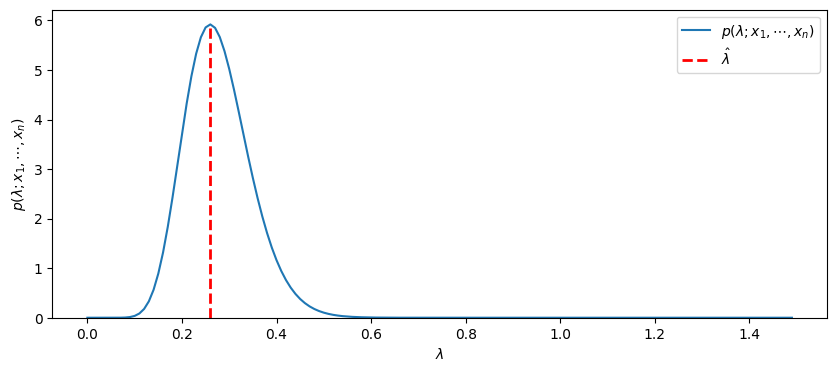

In [9]:
plt.figure(figsize=(10, 4))
lam_range=np.arange(0, 1.5, 0.01)
plt.plot(lam_range, post_exp(lam_range), label=r'$p(\lambda;x_1,\cdots,x_n)$')
lam0 = 1/x_obs.mean()
plt.plot([lam0, lam0], [0, post_exp(lam0)], color='red', linewidth=2, linestyle='--', label='$\hat{\lambda}$')
plt.ylim(bottom=0)
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$p(\lambda;x_1,\cdots,x_n)$')
plt.legend()
plt.show()

Possiamo calcolare la varianza di $\lambda$ come $\sigma^2_{\lambda} = \mathbb{E}(\lambda^2) - \mathbb{E}(\lambda)^2$.
I due valori di aspettazione possono essere ancora calcolati numericamente, consideando che:

$\displaystyle \mathbb{E}[\lambda^k] = \int_0^\infty\!\! \lambda^k f(\lambda)\,\mathrm{d}\lambda$

Anche qui, una soluzione analitica è possibile e fornita con la libreria ```scipy```. L'integrazione numerica per alcuni valori dei parametri potrebbe dare problemi di precisione.

In [10]:
sigma_lam = gamma.std(x_size+1, scale=1/x_sum)
print("sigma(lam):", sigma_lam)

sigma(lam): 0.069220750985987


Proviamo a sovrapporre una gaussiana sulla nostra PDF. Potremo provare a ripetere l'esercizio aumentando il valore di $n$. Vedremo che la PDF posterior sarà sempre più simile ad una distribuzione gaussiana.

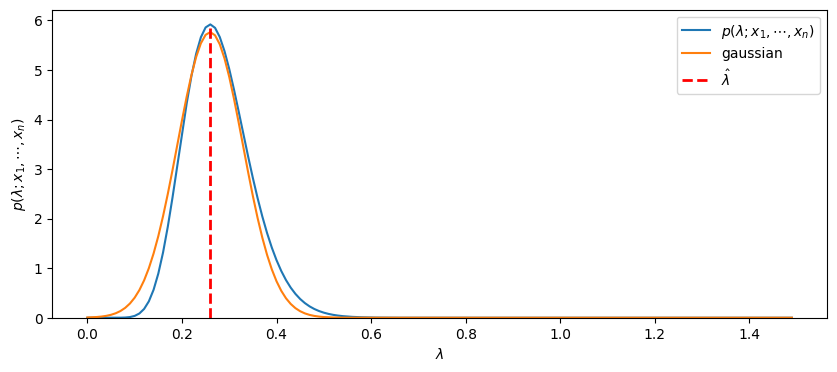

In [11]:
plt.figure(figsize=(10, 4))
lam1, lam2, lam_step = 0, 1.5, 0.01
lam_range=np.arange(lam1, lam2, lam_step)
post_exp_v = np.vectorize(post_exp)
plt.plot(lam_range, post_exp_v(lam_range), label=r'$p(\lambda;x_1,\cdots,x_n)$')
plt.plot(lam_range, norm.pdf(lam_range, loc=lam0,scale=sigma_lam), label='gaussian')
lam0 = 1/x_obs.mean()
plt.plot([lam0,lam0], [0,post_exp(lam0)], color='red', linewidth=2, linestyle='--', label=r'$\hat{\lambda}$')
plt.ylim(bottom=0)
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$p(\lambda;x_1,\cdots,x_n)$')
plt.legend()
plt.show()

## Inferenza bayesiana come apprendimento

L'uso della funzione di verosimiglianza per misure ripetute permette un'interpretazione interessante dell'inferenza bayesiana:

$\displaystyle p(\theta | x_1,\cdots,x_n) = \frac{p(x_1, \cdots, x_n;\theta)\,\pi(\theta)}{\int p(x_1, \cdots, x_n;\theta^\prime)\,\pi(\theta^\prime)\,\mathrm{d}\theta^\prime}$

dove:

$\displaystyle p(x_1, \cdots, x_n;\theta) = \prod_{i=1}^n p(x_i;\theta)$

Abbiamo quindi:

$\displaystyle p(\theta | x_1,\cdots,x_n) = \frac{\prod_{i=1}^n p(x_i;\theta)\,\pi(\theta)}{\int \prod_{i=1}^n p(x_i;\theta^\prime)\,\pi(\theta^\prime)\,\mathrm{d}\theta^\prime}$

Considerando che il denominatore è solo un termine di normalizzazione, possiamo porlo uguale ad $1/C_n$:

$\displaystyle p(\theta;x_1,\cdots,x_n) = C_n\prod_{i=1}^n p(x_i;\theta)\,\pi(\theta)$

Immaginiamo di applicare questo approccio ripetutamente, prima per $x_1$, poi per $x_2$, fino ad $x_n$. Otterremo una successione di PDF ciascuna che si può ottenere dalla precedente:

$\displaystyle p^{(0)}(\theta) = C_0\pi(\theta)$

$\displaystyle p^{(1)}(\theta) = C_1p(x_1;\theta)\,\pi(\theta) = K_1p(x_1;\theta) p^{(0)}(\theta)$

$\displaystyle p^{(2)}(\theta) = C_2p(x_1, x_2;\theta)\,\pi(\theta) = K_2p(x_2;\theta) p^{(1)}(\theta)$

$\cdots$

$\displaystyle p^{(n)}(\theta) = C_np(x_1,\cdots, x_n;\theta)\,\pi(\theta) = K_np(x_n;\theta) p^{(n-1)}(\theta)$

Si può quindi considerare il processo di inferenza bayesiana come apprendimento, via via che le nuove informazioni sono incluse nel calcolo. Partendo da una *prior*, ad ogni osservazione, la PDF viene modificata ottenendo una *posterior* aggiornata.

x_1 = 0.832
x_2 = 0.325
x_3 = 0.056
x_4 = 0.305
x_5 = 0.306
x_6 = 0.128
x_7 = 0.445
x_8 = 0.319
x_9 = 0.425
x_10 = 0.509
x_11 = 0.162
x_12 = 1.127
x_13 = 0.622
x_14 = 2.625
x_15 = 0.415


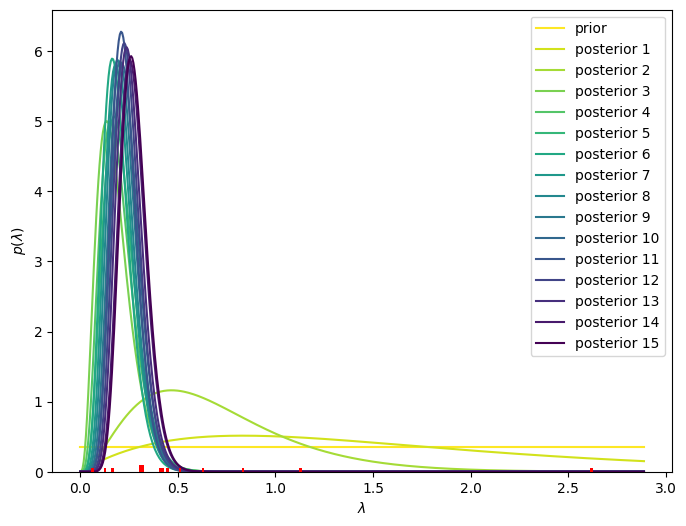

In [12]:
plt.figure(figsize=(8, 6))
plt.hist(1./x_obs, bins=200, density=False, weights=[0.05]*len(x_obs), color='r', zorder=100)
npts = 500
lam1, lam2 = 0, (1./x_obs).max()*1.1
lam_step = (lam2 - lam1)/npts
lam_range = np.linspace(lam1, lam2, npts)
def prior_unif(lam):
    return 1
def prior_exp(lam):
    return math.exp(-20*lam)
prior = prior_unif # qui si puà cambiare in prior_exp e vedere la differenza
colormap = plt.get_cmap('viridis')
colors = np.linspace(1, 0, len(x_obs)+1)
posterior = np.vectorize(prior)(lam_range)
posterior = posterior/posterior.sum()/lam_step
plt.plot(lam_range,posterior, label='prior', color=colormap(0.999))
for x_i, c, i in zip(x_obs, colors[1:], range(1,len(x_obs)+1)):
    posterior = posterior * lam_range*np.exp(-lam_range*x_i)
    posterior = posterior/posterior.sum()/lam_step
    print('x_{:d} = {:.3f}'.format(i, 1/x_i))
    plt.plot(lam_range, posterior, label='posterior {:d}'.format(i), color=colormap(c))
plt.legend()
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$p(\lambda)$')
plt.show()

Proviamo un esempio simile con una distribuzione gaussiana, dove ci aspettiamo una distribuzione più simmetrica.

Abbiamo a disposizione due *prior*:
* una PDF uniforme
* una PDF esponenziale

Vedremo che, al crescere del numero di osservazioni, la sensibilità alla *prior* diventa sempre meno importante.

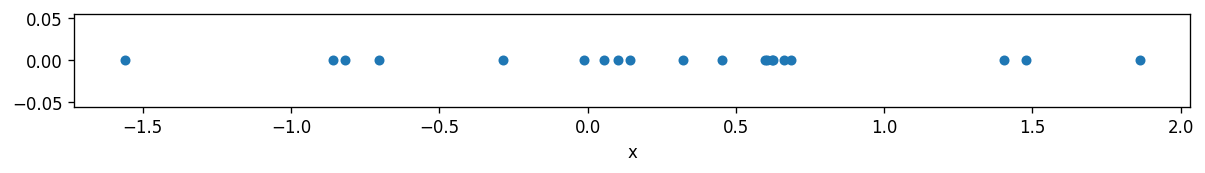

In [13]:
from scipy.stats import norm
mu = 0
x_obs = norm.rvs(size=20)
plt.figure(figsize=(12,1), dpi=120)
plt.plot(x_obs, np.zeros(len(x_obs)), '.', markersize=10)
plt.xlabel('x')
plt.show()

Possiamo comporre insieme le varie immagini con il modulo [```imageio```](https://imageio.readthedocs.io/en/stable/examples.html)

In [14]:
import imageio.v2 as imageio

def prior_unif(mu):
    return 1
def prior_exp(mu):
    return math.exp(-0.4*mu)
# prior choice
prior = prior_exp
def plot_bayes(prior, name):
    plt.figure(figsize=(8,6), dpi=100)
    mu1, mu2, n_mu = -5, 5, 1000
    mu_step = (mu2 - mu1)/n_mu
    mu_range=np.linspace(mu1, mu2, n_mu)
    colormap = plt.get_cmap('viridis')
    colors = np.linspace(1, 0, len(x_obs)+1)
    posterior = np.vectorize(prior)(mu_range)
    posterior = posterior/posterior.sum()/mu_step
    plt.plot(mu_range, posterior, label='prior', color=colormap(0.999))
    plt.xlabel(r'$\mu$')
    plt.ylabel(r'$p(\mu)$')
    plt.legend(loc='upper right')
    plt.savefig('img_out/bayesian-posterior-0.png')
    for x_i, c, i in zip(x_obs, colors[1:], range(1,len(x_obs)+1)):
        plt.hist(x_obs[:i],bins=40, density=False, weights=[0.05]*len(x_obs[:i]), color='r', zorder=100)
        posterior = posterior*norm.pdf(mu_range, loc=x_i)
        posterior = posterior/posterior.sum()/mu_step
        print('x_{:d} = {:.3f}'.format(i, x_i))
        plt.plot(mu_range, posterior, label='posterior {:d}'.format(i), color=colormap(c))
        plt.legend(loc='upper right')
        plt.savefig('img_out/bayesian-posterior-{}-{:d}.png'.format(name, i))
    plt.show()
    with imageio.get_writer('img_out/bayesian-{}.gif'.format(name), mode='I', fps=3) as writer:
        for filename in ['img_out/bayesian-posterior-{}-{:d}.png'.format(name, i) for i in range(1, len(x_obs)+1)]:
            image = imageio.imread(filename)
            writer.append_data(image)
            

x_1 = 0.686
x_2 = 1.861
x_3 = 0.322
x_4 = 0.600
x_5 = 0.622
x_6 = -0.857
x_7 = 1.477
x_8 = -0.286
x_9 = -1.559
x_10 = -0.013
x_11 = 0.056
x_12 = 0.662
x_13 = -0.702
x_14 = 0.605
x_15 = 1.405
x_16 = 0.145
x_17 = 0.454
x_18 = -0.817
x_19 = 0.103
x_20 = 0.626


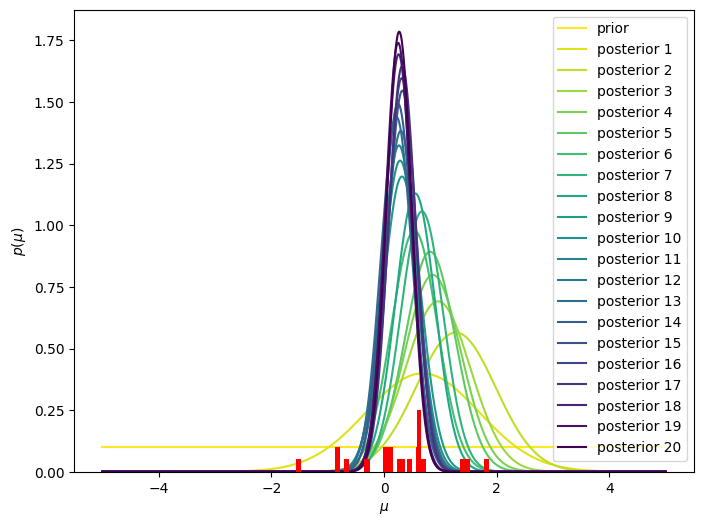

In [15]:
plot_bayes(prior_unif, 'unif')

x_1 = 0.686
x_2 = 1.861
x_3 = 0.322
x_4 = 0.600
x_5 = 0.622
x_6 = -0.857
x_7 = 1.477
x_8 = -0.286
x_9 = -1.559
x_10 = -0.013
x_11 = 0.056
x_12 = 0.662
x_13 = -0.702
x_14 = 0.605
x_15 = 1.405
x_16 = 0.145
x_17 = 0.454
x_18 = -0.817
x_19 = 0.103
x_20 = 0.626


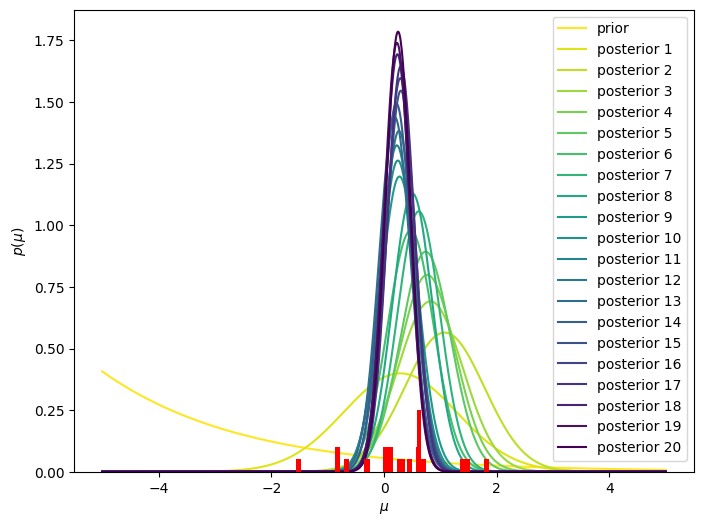

In [16]:
plot_bayes(prior_exp, 'exp')

<img src="img_out/bayesian-unif.gif" width="750" align="center"> 

<img src="img_out/bayesian-exp.gif" width="750" align="center"> 

## Distribuzioni a priori informative e non informative

Se non abbiamo informazioni riguardo un parametro, dobbiamo usare una PDF a priori che non sia troppo differente tra un valore e l'altro. Una distribuzione *uniforme* esprime la nostra ignoranza, ossia il massimo dell'indecisione tra i possibili valori.

Bisogna notare che una PDF costante su un intervallo infinito non è integrabile, quindi non potrebbe essere normalizzata. Lo stesso vale per altre funzioni (es.: $1/x$). Si parla in questi casi di **distribuzione impropria**. Si tratta di una classe di PDF che, se trattate con rigore matematico, non possono essere funzioni ordinarie, così come la delta di Dirac.

Il fatto però che la PDF sia moltiplicata per la funzione di verosimiglianza, che tipicamente si smorza rapidamente per valori estremi, risolve questo problema.

Se invece abbiamo informazioni a priori sui possibili valori, possiamo usare una PDF che modelli il nostro grado di conoscenza sul valore vero, ovvero sull'incertezza che abbiamo.

# Spunti per esercizi
* Determinare con l'inferenza bayesiana la probabilità di ottenere "testa" nel lancio di una moneta, possibilmente truccata, trovando la distribuzione di probabilità a posteriori per successivi lanci di moneta simulati con una probabilità $p$ non necessariamente uguale a 0.5.

Ricordiamo la distribuzione di Bernoulli (testa=1, croce=0):

* $P(0;p) = 1-p$
* $P(1;p) = p$

Estratto $x$ che può valere 0 o 1:

$\displaystyle f(p | x) = \frac{P(x;p)\,\pi(p)}{\int_0^1 P(x;p^\prime)\,\pi(p^\prime)\,\mathrm{d}p^\prime}$

Assumiamo $\pi(p)=1$.



In [ ]:
from scipy.stats import bernoulli

In [ ]:
p0 = 0.75
x_obs = bernoulli.rvs(p0, size=18)

In [ ]:
x_obs

In [ ]:
def prior(p):
    return 1
p1, p2, n_p = 0, 1, 1001
p_step = (p2 - p1)/n_p
p_range=np.linspace(p1, p2, n_p)
colormap = plt.get_cmap('viridis')
colors = np.linspace(1, 0, len(x_obs) + 1)
posterior = np.vectorize(prior)(p_range)
posterior = posterior/(posterior.sum()*p_step)

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(p_range, posterior, label='prior', color=colormap(0.999))
plt.xlabel(r'$p$')
plt.ylabel(r'$p(p)$')
i = 1
one_minus_p_range = 1 - p_range
for x_i, c in zip(x_obs, colors[1:]):
#    posterior *= bernoulli.pmf(x_i, p_range)
#    posterior *= (p_range if x_i==1 else one_minus_p_range)
    if x_i == 1: posterior *= p_range
    else: posterior *= one_minus_p_range
    posterior = posterior/((posterior[:-1]).sum()*p_step)
    x_partial = x_obs[:i]
    x_count = x_partial[x_partial == 1].shape[0]
    print('x_{:d} = {:d}, n/N = {:.3f}'.format(i, x_i, x_count/i) )
    plt.plot(p_range, posterior, label='posterior {:d}'.format(i), color=colormap(c))
    i += 1
plt.hist(x_obs, bins=40, density=False, weights=[0.05]*len(x_obs[:i]), color='r', zorder=100)
plt.xlim(0,1)
plt.legend(ncol=2)
plt.show()

Il risultato finale, se la prior $\pi(p)$ è uniforme, è il prodotto di $k$ termini $p$ e di $N-n$ termini $1-p$, dove $n$ e $N-n$ sono il numero di "teste" e di "croci". 

La posterior finale è quindi una distribuzione beta:

$p(p;x_1,\cdots,x_n) = C p^n(1-p)^{N-n} = \beta(p; n+1, N-n+1)$

Dove $C$ è un coefficiente di normalizzazione.

Queto è consistente con il risultato ottenuto per l'inferenza del parametri $p$ in una distribuzione binomiale.